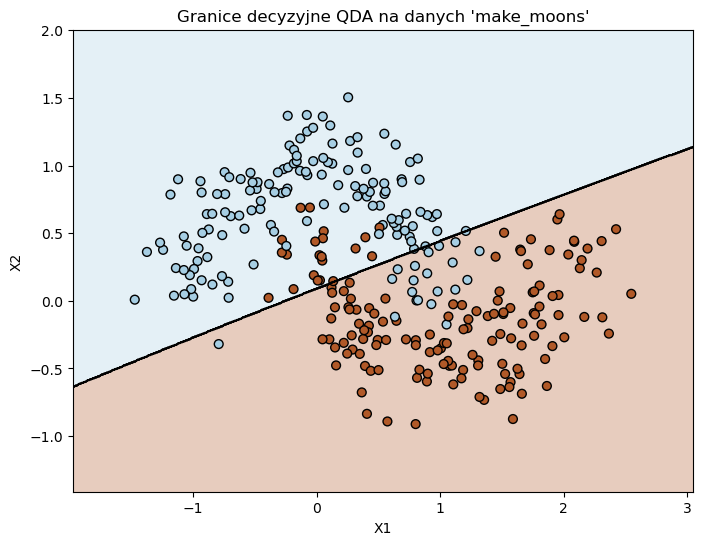

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Tworzymy dane, które QDA nie potrafi dobrze oddzielić
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Tworzymy model QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X, y)

# Tworzymy siatkę do wizualizacji
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 500),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 500))
Z = qda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Rysujemy granicę decyzyjną
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
plt.contour(xx, yy, Z, colors='k', linewidths=1)  # Wyraźna linia granicy
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap=plt.cm.Paired, edgecolor='k')
plt.title("Granice decyzyjne QDA na danych 'make_moons'")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()



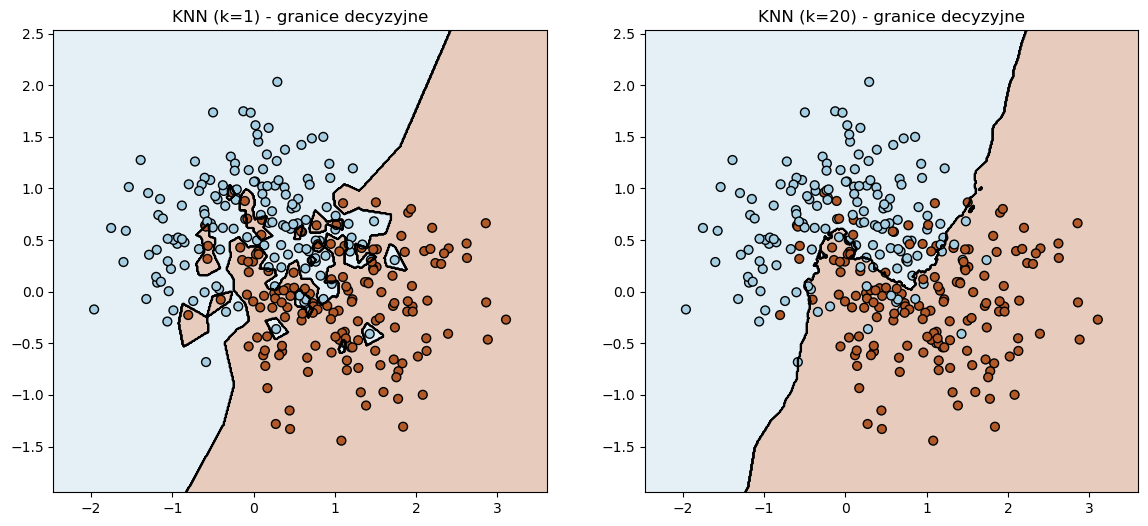

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier

# Tworzymy dane 2D
X, y = make_moons(n_samples=300, noise=0.4, random_state=42)

# Tworzymy modele KNN
knn1 = KNeighborsClassifier(n_neighbors=1)
knn20 = KNeighborsClassifier(n_neighbors=20)

knn1.fit(X, y)
knn20.fit(X, y)

# Przygotowujemy siatkę do wizualizacji granic
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 500),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 500))
grid = np.c_[xx.ravel(), yy.ravel()]

# Predykcja dla siatki
Z1 = knn1.predict(grid).reshape(xx.shape)
Z20 = knn20.predict(grid).reshape(xx.shape)

# Wizualizacja
plt.figure(figsize=(14,6))

# KNN = 1
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z1, alpha=0.3, cmap=plt.cm.Paired)
plt.contour(xx, yy, Z1, colors='k', linewidths=1)
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap=plt.cm.Paired, edgecolor='k')
plt.title("KNN (k=1) - granice decyzyjne")

# KNN = 20
plt.subplot(1,2,2)
plt.contourf(xx, yy, Z20, alpha=0.3, cmap=plt.cm.Paired)
plt.contour(xx, yy, Z20, colors='k', linewidths=1)
plt.scatter(X[:,0], X[:,1], c=y, s=40, cmap=plt.cm.Paired, edgecolor='k')
plt.title("KNN (k=20) - granice decyzyjne")

plt.show()


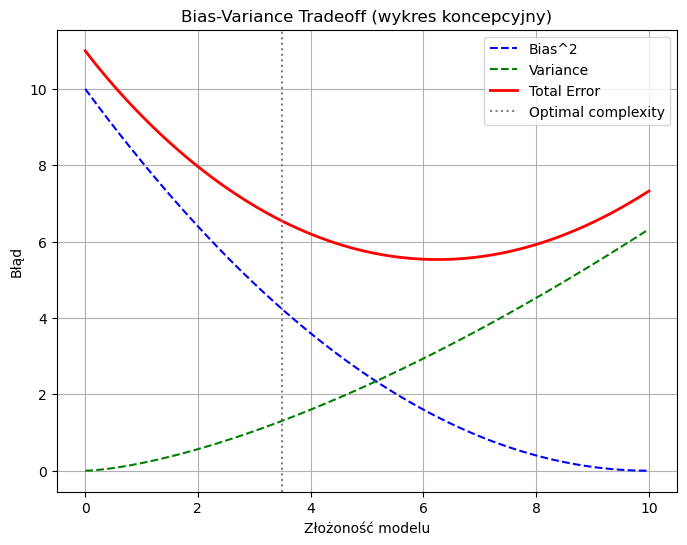

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Przykładowe dane koncepcyjne
model_complexity = np.linspace(0, 10, 100)

# Składowe błędu
bias_squared = (10 - model_complexity)**2 / 10
variance = model_complexity**1.5 / 5
irreducible_error = 1.0

# Całkowity błąd
total_error = bias_squared + variance + irreducible_error

# Rysowanie wykresu
plt.figure(figsize=(8,6))
plt.plot(model_complexity, bias_squared, label='Bias^2', linestyle='--', color='blue')
plt.plot(model_complexity, variance, label='Variance', linestyle='--', color='green')
plt.plot(model_complexity, total_error, label='Total Error', color='red', linewidth=2)
plt.axvline(x=3.5, color='gray', linestyle=':', label='Optimal complexity')

plt.title("Bias-Variance Tradeoff (wykres koncepcyjny)")
plt.xlabel("Złożoność modelu")
plt.ylabel("Błąd")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import glm

# Przykładowe dane
data = pd.DataFrame({
    'X1': [1,2,3,4,5,6],
    'Y': [2,3,4,7,6,9]
})

# Dopasowanie modelu Poissona
model = glm('Y ~ X1', data=data, family=sm.families.Poisson()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                    6
Model:                            GLM   Df Residuals:                        4
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10.540
Date:                Mon, 27 Oct 2025   Deviance:                      0.68932
Time:                        00:14:48   Pearson chi2:                    0.727
No. Iterations:                     4   Pseudo R-squ. (CS):             0.6466
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5867      0.511      1.149      0.2

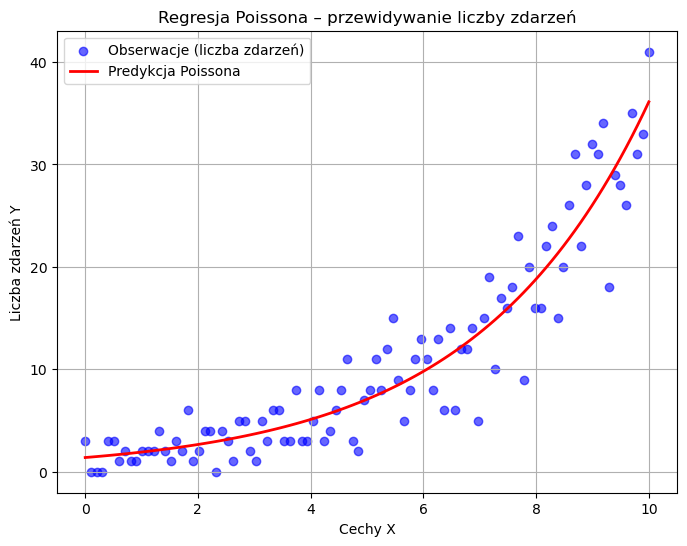

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import glm
import pandas as pd

# Generujemy dane przykładowe
np.random.seed(42)
X = np.linspace(0, 10, 100)
# Oczekiwana liczba zdarzeń rośnie wykładniczo z X
lambda_ = np.exp(0.3 * X + 0.5)
# Losowa zmienna z rozkładu Poissona
Y = np.random.poisson(lam=lambda_)

# Tworzymy DataFrame
data = pd.DataFrame({'X': X, 'Y': Y})

# Dopasowanie regresji Poissona
model = glm('Y ~ X', data=data, family=sm.families.Poisson()).fit()
predicted_lambda = model.predict(data['X'])

# Wizualizacja
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='blue', alpha=0.6, label='Obserwacje (liczba zdarzeń)')
plt.plot(X, predicted_lambda, color='red', linewidth=2, label='Predykcja Poissona')
plt.xlabel('Cechy X')
plt.ylabel('Liczba zdarzeń Y')
plt.title('Regresja Poissona – przewidywanie liczby zdarzeń')
plt.legend()
plt.grid(True)
plt.show()
